# MicroPlant — Exploratory Data Analysis (EDA)

This notebook explores the MicroPlant dataset before training.

Goals:
- Understand dataset structure
- Check class distribution
- Inspect image properties
- Verify preprocessing pipeline

This step ensures the data is suitable for training a lightweight CNN model.

In [11]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from src.preprocessing import make_dataset, get_dataloaders, show_samples

## Load Dataset

We use the custom `make_dataset` class to:
- Read all image paths
- Assign labels based on folder names

In [12]:
DATA_DIR = "../data/MicroPlantDataset"

dataset = make_dataset(DATA_DIR)

print("Total samples:", len(dataset))
print("Classes:", dataset.classes)

Total samples: 3171
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']


## Class Distribution

We analyze how images are distributed across classes.

This helps identify:
- Class imbalance
- Potential bias in training

In [13]:
labels = dataset.labels()
class_counts = Counter(labels)

class_names = dataset.classes
counts_named = {class_names[k]: v for k, v in class_counts.items()}

counts_named

{'Apple___Apple_scab': 630,
 'Apple___Black_rot': 621,
 'Apple___Cedar_apple_rust': 275,
 'Apple___healthy': 1645}

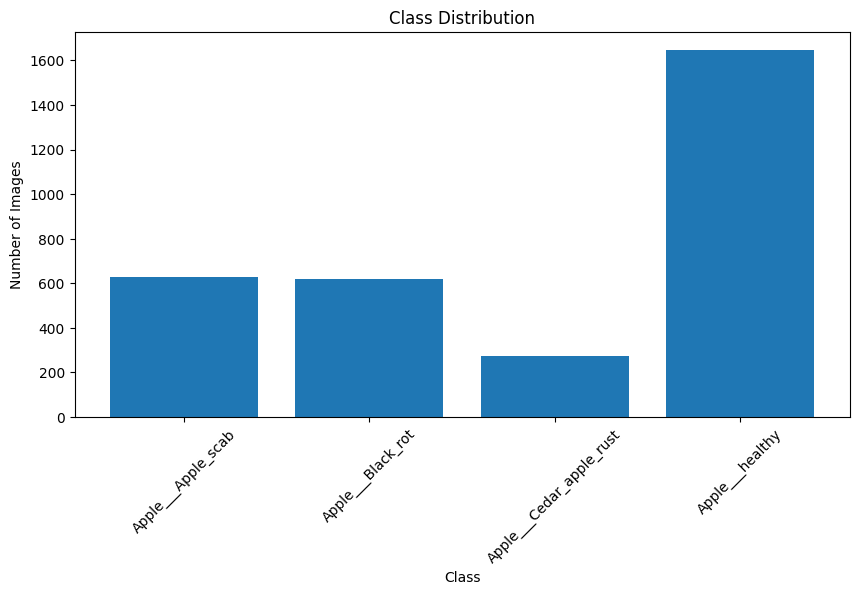

In [14]:
plt.figure(figsize=(10,5))
plt.bar(counts_named.keys(), counts_named.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

### Insight

The dataset shows class imbalance:

- Apple healthy has significantly more samples
- Apple cedar rust has the fewest samples

The imbalance ratio is approximately 6:1.

This may bias the model toward predicting the dominant class (healthy).

### Implication
To address this during training:
- Data augmentation is important
- Weighted loss or sampling may be considered

In [15]:
max_class = max(class_counts.values())
min_class = min(class_counts.values())

print("Max samples:", max_class)
print("Min samples:", min_class)
print("Imbalance ratio:", round(max_class / min_class, 2))

Max samples: 1645
Min samples: 275
Imbalance ratio: 5.98


## Data Pipeline Check

We now load the dataset using the full training pipeline:
- Train / Validation / Test split
- Augmentation applied to training set

In [16]:
train_loader, val_loader, test_loader, class_names = get_dataloaders(DATA_DIR)

## Sample Images (Augmented)

We visualize samples from the training loader.

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


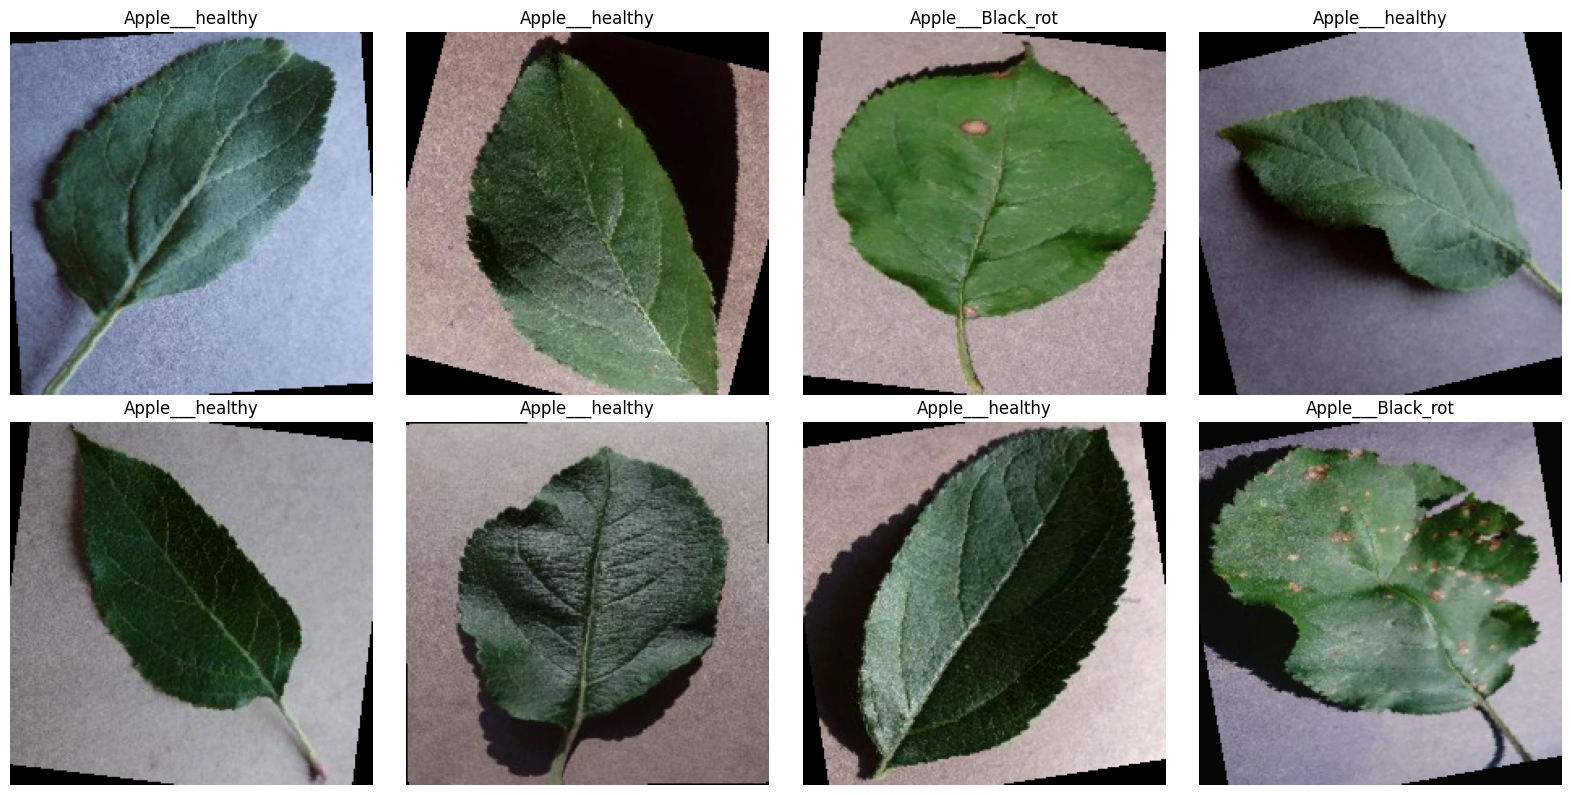

In [17]:
show_samples(train_loader, class_names, n_images=8)

## Image Size Analysis

Before preprocessing, images may have different resolutions.

We analyze:
- Width distribution
- Height distribution
- Consistency of image sizes

In [18]:
widths, heights = [], []

for i in range(len(dataset)):
    img, _ = dataset[i]
    w, h = img.size
    widths.append(w)
    heights.append(h)

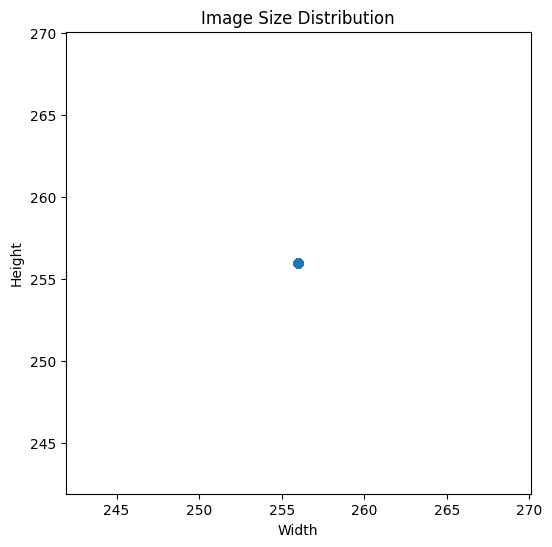

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

### Insight

If image sizes vary significantly:
- Resizing is necessary (already applied in pipeline)

Consistent resizing ensures:
- Stable input to CNN
- Better convergence

In [20]:
unique_sizes = set(zip(widths, heights))
print("Number of unique sizes:", len(unique_sizes))

Number of unique sizes: 1


## Final EDA Summary

- Number of classes: 4  
- Dataset size: 3171 
- Class distribution: heavily imbalanced 
- Image sizes: consistent
- Augmentation: applied (flip, rotation, color jitter)  

### Conclusion
The dataset is suitable for training a CNN model.

Resizing to 224×224 and applying augmentation helps improve generalization, especially for a lightweight architecture like MicroPlant.